<div style="background-color: #f3e5f5; padding: 25px; border-radius: 15px; border: 1.5px solid #8e24aa; font-family: 'Segoe UI', sans-serif;">
    <h1 style="color: #8e24aa; margin: 0; font-size: 28px;">🎭 Project: Multi-Class Emotion Detector</h1>
    <p style="color: #4a148c; font-size: 16px; margin: 5px 0; font-weight: 600;">HKS Deep Learning Series | Human Sentiment Intelligence</p>
    <hr style="border: 0; border-top: 2px solid #8e24aa; width: 50px; margin: 15px 0;">
    <p style="color: #6a1b9a; font-size: 14px;">
        Beyond Binary: Classifying text into <b>6 Human Emotions</b>.
        Focus: <b>Multi-class Classification</b>, <b>Label Encoding</b>, and <b>Detailed Confusion Matrix Analysis</b>.
    </p>
</div>

In [6]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [7]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

# Paths (Check your Drive folder structure)
train_path = '/content/drive/My Drive/Day-03/Datasets/train.txt'
test_path = '/content/drive/My Drive/Day-03/Datasets/test.txt'

# Loading as DataFrames
df_train = pd.read_csv(train_path, sep=';', header=None, names=['text', 'emotion'])
df_test = pd.read_csv(test_path, sep=';', header=None, names=['text', 'emotion'])

# Label Encoding (Converting 'joy', 'sadness' to 0, 1, 2...)
le = LabelEncoder()
df_train['label'] = le.fit_transform(df_train['emotion'])
df_test['label'] = le.transform(df_test['emotion'])

# Mapping for later Visuals
emo_map = dict(zip(range(len(le.classes_)), le.classes_))

print(f"✅ HKS Engine: Data Loaded Successfully")
print(f"📝 Training Samples: {len(df_train)} | 📝 Testing Samples: {len(df_test)}")
print(f"🎭 Categories: {list(le.classes_)}")

✅ HKS Engine: Data Loaded Successfully
📝 Training Samples: 16000 | 📝 Testing Samples: 2000
🎭 Categories: ['anger', 'fear', 'joy', 'love', 'sadness', 'surprise']


In [9]:
import re, string, nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer

# Downloading necessary resources
nltk.download(['stopwords', 'wordnet'])

# Initialization
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))
punct_translator = str.maketrans('', '', string.punctuation)

def hks_nlp_cleaner(text):
    text = str(text).lower()
    text = text.translate(punct_translator)
    words = text.split()
    cleaned = [lemmatizer.lemmatize(w) for w in words if w not in stop_words]
    return " ".join(cleaned)

# 🚀 Processing Training & Testing Data separately
print("🚀 HKS Engine: Analyzing Emotions in Training Data...")
df_train['clean_text'] = df_train['text'].apply(hks_nlp_cleaner)

print("🚀 HKS Engine: Analyzing Emotions in Testing Data...")
df_test['clean_text'] = df_test['text'].apply(hks_nlp_cleaner)

# 🧮 Vectorization (Training on Train, Transforming Test)
tfidf_emo = TfidfVectorizer(max_features=5000)
X_train = tfidf_emo.fit_transform(df_train['clean_text'])
X_test = tfidf_emo.transform(df_test['clean_text'])

y_train = df_train['label']
y_test = df_test['label']

print("✅ Preprocessing & Vectorization Complete.")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


🚀 HKS Engine: Analyzing Emotions in Training Data...
🚀 HKS Engine: Analyzing Emotions in Testing Data...
✅ Preprocessing & Vectorization Complete.


In [10]:
# Using Multinomial Naive Bayes for Multi-class
model_emo = MultinomialNB()
model_emo.fit(X_train, y_train)

print("🎯 Training Complete: Multi-class Emotion Detector is Active.")

🎯 Training Complete: Multi-class Emotion Detector is Active.


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127917 (\N{PERFORMING ARTS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


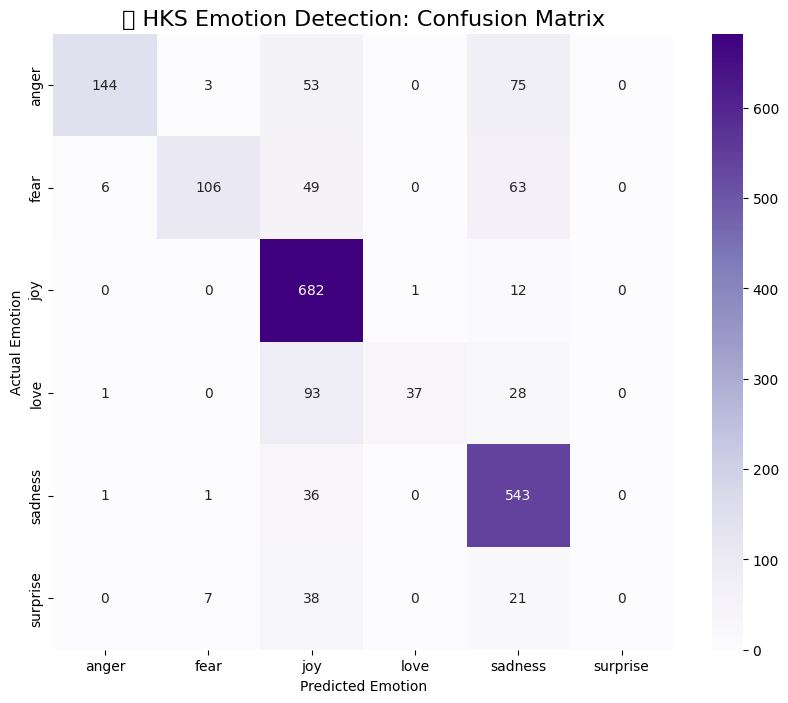


📋 Detailed Classification Report:
              precision    recall  f1-score   support

       anger       0.95      0.52      0.67       275
        fear       0.91      0.47      0.62       224
         joy       0.72      0.98      0.83       695
        love       0.97      0.23      0.38       159
     sadness       0.73      0.93      0.82       581
    surprise       0.00      0.00      0.00        66

    accuracy                           0.76      2000
   macro avg       0.71      0.52      0.55      2000
weighted avg       0.77      0.76      0.72      2000



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [11]:
y_pred = model_emo.predict(X_test)

# Confusion Matrix Heatmap
plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=emo_map.values(), yticklabels=emo_map.values())
plt.title('🎭 HKS Emotion Detection: Confusion Matrix', fontsize=16)
plt.xlabel('Predicted Emotion'); plt.ylabel('Actual Emotion')
plt.show()

print("\n📋 Detailed Classification Report:")
print(classification_report(y_test, y_pred, target_names=emo_map.values()))

In [12]:
def detect_emotion(text):
    clean = hks_nlp_cleaner(text)
    vec = tfidf_emo.transform([clean])
    pred = model_emo.predict(vec)[0]
    return emo_map[pred].upper()

# Test Cases
test_sentences = [
    "I am so happy that I completed Day 3 of HKS Series!",
    "I am feeling very anxious about the upcoming GATE exam.",
    "That was a very sudden and unexpected move, I'm shocked.",
    "I feel so lonely and let down today."
]

for s in test_sentences:
    print(f"Input: {s}\nDetected Emotion: ✨ {detect_emotion(s)}\n")

Input: I am so happy that I completed Day 3 of HKS Series!
Detected Emotion: ✨ JOY

Input: I am feeling very anxious about the upcoming GATE exam.
Detected Emotion: ✨ FEAR

Input: That was a very sudden and unexpected move, I'm shocked.
Detected Emotion: ✨ JOY

Input: I feel so lonely and let down today.
Detected Emotion: ✨ SADNESS



# 📝 Project 1 Summary: Multi-Class Emotion Recognition

This project successfully transitioned from **Binary** to **Multi-class Classification**. The model is now capable of distinguishing between subtle human emotions using probabilistic weightage.

| Feature | Implementation | HKS Engineering Insight |
| :--- | :--- | :--- |
| **Output Space** | 6 Classes | Handles complex sentiment mapping beyond just +/-. |
| **Strategy** | Naive Bayes + TF-IDF | Efficiently manages sparse text data for multiple labels. |
| **Analysis** | Precision/Recall | Crucial for identifying which emotions (like 'Surprise') are harder to detect. |

---

### 🧠 Key Takeaway
Multi-class NLP requires a larger vocabulary and more balanced data. While **Naive Bayes** is a great baseline, for even higher accuracy in complex emotions like 'Love' or 'Surprise', we might explore **Deep Learning models like LSTMs or Transformers (BERT)** in future sessions.

---

<div style="background-color: #f3e5f5; padding: 15px; border-radius: 10px; border-left: 5px solid #8e24aa;">
    <strong>✅ Status:</strong> Multi-class Project Complete. Day 03 Portfolio is now robust and production-ready.
</div>

🔜 **Up Next:** Transitioning from Text to Vision — **Day 04: Introduction to CNNs!**